In [23]:
from graph import create_graph

In [24]:
state_graph = create_graph()
graph_v0 = state_graph.compile()  # -- no memory

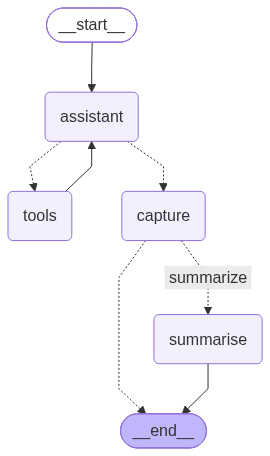

In [25]:
from IPython.display import Image, display
try:
    display(Image(graph_v0.get_graph().draw_mermaid_png()))
except Exception as ex:
    print("Couldnot render png")


## Lets talk to the graph

* A customer with some concern

In [26]:
from langchain_core.messages import HumanMessage

turn_1 = graph_v0.invoke({
    "messages": [HumanMessage("I need a fix for skin detan")]
})

turn_1["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': "I'd love to help you with your skin care needs, but I'm currently not seeing any products in our catalog specifically designed for detanning. \n\nCould you tell me a little bit about your skin type (such as dry, oily, or combination) so I can see if we have any other products that might suit your general routine?", 'extras': {'signature': 'EmAKXgFpFH0TxX4RJT5my/J8Lq1dGPS5VHDeQ6j76W78u0q+m5QudjWOE76Xvag36CwgRE2k3ALJhtrKKQRfUa0moGYfHUHWp2SSUma6IHniLghJmqWc2WxMNJITWQ0JGmw='}}]


## Problem

* We are about to ask a follow up question
* The agent has no idea

In [27]:
turn_2 = graph_v0.invoke({
    "messages": [HumanMessage("Which product did you just recommend?")]
})
turn_2["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': "Hello! I haven't recommended any products yet since we're just getting started. \n\nTo help me find the right product for you, could you please tell me what kind of personal care or cosmetic concern you're looking to address today?", 'extras': {'signature': 'EmAKXgFpFH0TNKCtjjuZdAJCn7XgkPLY1lN4zWfAvb46wCCHhE9EcII9dBAR36fwez9ib5oKLSNdi9SpfMOmizsnv2WzLp9mVsTg6qS5gKYD26PY0KyICxYp627721O42+4='}}]


In [28]:
print(f"Messages at the end of turn_1: ", len(turn_1["messages"]))
print(f"Messages at the end of turn_2: ", len(turn_2["messages"]))

Messages at the end of turn_1:  4
Messages at the end of turn_2:  2


In [29]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph_v1 = state_graph.compile(checkpointer=checkpointer)


In [32]:
cfg = {"configurable": {"thread_id": "some-conversation-id"}}

In [33]:
turn_1 = graph_v1.invoke({
    "messages": [HumanMessage("I need a fix for skin detan")]
}, cfg)

turn_1["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': "It looks like our current product catalog only contains test sample entries and doesn't feature any products specifically designed for skin detanning. \n\nBecause we don't have a suitable product in our range right now, I cannot recommend one for you. If you are dealing with significant sun damage or stubborn tanning, it might be a good idea to consult a qualified dermatologist for personalized advice. \n\nIs there any other personal care or cosmetic concern I can help you with today?", 'extras': {'signature': 'EmAKXgFpFH0TaXSFSGmdJROIMAQJy/npAJ+8k4f8DLM8uaQr16GQe/EtO6S4neUcP8EoVZouy0zdP9LoWHJ+DOVwPRV3wPm7uYEs21mWAYoBBWO1XZgM4nwDWbp74aiYF7g='}}]


In [34]:
turn_2 = graph_v1.invoke({
    "messages": [HumanMessage("Which product did you just recommend?")]
}, cfg)
turn_2["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': "I didn't recommend any product at all! Since our catalog currently only has test samples and nothing for detangling or detanning, I let you know that we don't have a suitable product for you. \n\nWould you like to explore anything else we might be able to help with?", 'extras': {'signature': 'EmAKXgFpFH0TBoBKN03h+7/e7CHqjMJNcmIfz1UZDBJJC2jOBy5tEWQ7+zwrzog1z8keGo056Y1FQb2kfS4IGW5Cn2/t+34u7oHlTyUNsJxauZ8Vxuxw9qFJ42n6IoPBkIs='}}]


In [35]:
print(f"Messages at the end of turn_1: ", len(turn_1["messages"]))
print(f"Messages at the end of turn_2: ", len(turn_2["messages"]))

Messages at the end of turn_1:  6
Messages at the end of turn_2:  8


In [36]:
## Lets see whats inside a checkpoint

snapshot = graph_v1.get_state(cfg)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='I need a fix for skin detan', additional_kwargs={}, response_metadata={}, id='c92f125d-6e42-4ece-807a-973eab873f0d'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_all_products', 'arguments': '{}'}, '__gemini_function_call_thought_signatures__': {'call_2854820': 'EmAKXgFpFH0Tjr96sBPnZh2nIfkmaoCx91EYJZoftOWSPH6Yse8SplIfPy4HgyKcDBEEzJDV/lXupUiRuJNqHHpwoAhCBYQkJMzk6DwgZ3PEklHMIiv/t62VrTBGYZxGPhY='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a10513-22a2-77d1-8816-2bb53bfab7db-0', tool_calls=[{'name': 'get_all_products', 'args': {}, 'id': 'call_2854820', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 723, 'output_tokens': 12, 'total_tokens': 735, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='product_id | category | product_name | description | price

In [37]:
snapshot.config

{'configurable': {'thread_id': 'some-conversation-id',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1bfa89-ec46-6194-800c-c276d1014fd3'}}

In [38]:
for m in snapshot.values["messages"]:
    label = type(m).__name__
    if isinstance(m.content, str) and m.content != "" :
        body = m.content.replace("\n", " ")
    print(f"{label}  {body}")

HumanMessage  I need a fix for skin detan
AIMessage  I need a fix for skin detan
ToolMessage  product_id | category | product_name | description | price_inr | size | how_to_use | benefits | problems_it_solves | suitable_for TEST-SKIN-001 | skin_care | Sample Gentle Cleanser (Local Test Only) | Sample catalog entry for testing tool integration. This is not a real product. | N/A (sample) | N/A (sample) | Sample field only; not instructions for using a real product. | Sample field only; no product benefit is claimed. | Sample field only; does not claim to solve a skin concern. | Local testing only. TEST-SKIN-002 | skin_care | Sample Sunscreen (Local Test Only) | Sample catalog entry for testing tool integration. This is not a real product. | N/A (sample) | N/A (sample) | Sample field only; not instructions for using a real product. | Sample field only; no product benefit is claimed. | Sample field only; does not claim to solve a skin concern. | Local testing only.
AIMessage  product_id | 

In [39]:
## Adding multiple customers

def chat(thread_id="new-session"):
    cfg = {"configurable": {"thread_id": thread_id}}
    print(f"Chatting on thread: {thread_id}")
    while True:
        text = input("You: ")
        if text.strip().lower() in {'exit', 'quit', ''}:
            print("\n ended")
            break
        out = graph_v1.invoke({"messages": [HumanMessage(text)]}, cfg)
        print("Advisor: ", out["messages"][-1].content, "\n" )

In [40]:
# customer_1
chat("customer-1")

Chatting on thread: customer-1
Advisor:  [{'type': 'text', 'text': "We currently don't carry any tanning products in our product catalog. However, we do have items focused on daily sun protection, uneven-looking skin tone, and everyday skincare. \n\nAre you looking for something to help protect your skin from the sun, or are you hoping to address a different skin concern?", 'extras': {'signature': 'EmAKXgFpFH0TxPXqKTIGw48C+4DTAXQq1fspadDagfamF3OJPAcrnmfmqU8/zmSdmdqDxLmhr4hUVnaaipNrYkDiGn+vjWkABYnMERAjbxnKsajPazSnSHAWO1Qswc2FDzI='}}] 


 ended


In [41]:
chat("customer-2")

Chatting on thread: customer-2
Advisor:  [{'type': 'text', 'text': "Hello! I'd be happy to help you find the right skincare product. Could you tell me a bit about your skin type or what specific skin concerns you are looking to address?", 'extras': {'signature': 'EmAKXgFpFH0Ts/YpZdPSBP4yCUc/B7ljXIe9353PstS0KhF8rjgNVSHbRnAH/CPBtejnZc+w587gu54MkQoQ42sdYz5+uA8jfnQBAUz19RgyeYJSMTBRHRW57nK82XxPlyU='}}] 

Advisor:  [{'type': 'text', 'text': "Based on your interest in working on skin tone, we have the **Citrus Dew Even-Tone Serum**. \n\nIt's designed as a cosmetic serum for customers seeking to improve the appearance of dull or uneven-looking skin tone. It is priced at ₹649 for a 30 ml bottle and is used by applying a few drops to clean skin. \n\nPlease note that this is a cosmetic option and not a medical treatment; for any medical skin concerns, it's always best to consult a qualified professional.\n\nWould you like to go ahead with this product?", 'extras': {'signature': 'EmAKXgFpFH0TT9x1l

In [42]:
chat("customer-2")

Chatting on thread: customer-2

 ended


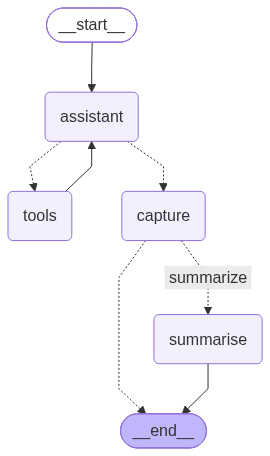

In [43]:
from graph import create_graph
graph_v1_with_summary = create_graph().compile()
from IPython.display import Image, display
try:
    display(Image(graph_v0.get_graph().draw_mermaid_png()))
except Exception as ex:
    print("Couldnot render png")
